#  Procesamiento Digital de Imágenes - TP07: Nociones de segmentación

**Objetivos de la guía:**

* Comparar ventajas y desventajas de operadores de detección de bordes y su desempeño ante el ruido.

* Comprender el funcionamiento de la Transformada de Hough (TH) y su utilidad práctica.

* Introducir conceptos básicos de segmentación basada en regiones.

In [1]:
# Configuración Inicial

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Checkbox, Dropdown, RadioButtons
import ipywidgets as widgets

def mostrar_imagenes(imagenes, titulos, figsize=(15, 5)):
    n = len(imagenes)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1: axs = [axs]
    for i in range(n):
        img = imagenes[i]
        if len(img.shape) == 3: img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img, cmap='gray', vmin=0, vmax=255)
        axs[i].set_title(titulos[i])
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

print("Entorno configurado. ¡Subí las imágenes ('patron_bordes.jpg', 'mosquito.jpg', 'letras1.tif', 'rosas.jpg', 'latas.png', etc.) al entorno de Colab!")


Entorno configurado. ¡Subí las imágenes ('patron_bordes.jpg', 'mosquito.jpg', 'letras1.tif', 'rosas.jpg', 'latas.png', etc.) al entorno de Colab!


## Ejercicio 1: Detección de bordes

Evaluaremos el desempeño de:
* Prewitt,
* Sobel,
* Laplaciano y
* Canny,

analizando el efecto de los parámetros y la robustez ante diferentes tipos de ruido.

In [2]:
def aplicar_prewitt(img):
    Kx_prewitt = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]], dtype=np.float32)
    Ky_prewitt = np.array([
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1]], dtype=np.float32)
    prewittx = cv2.filter2D(img, cv2.CV_64F, Kx_prewitt)
    prewitty = cv2.filter2D(img, cv2.CV_64F, Ky_prewitt)
    return cv2.magnitude(prewittx, prewitty)

def aplicar_sobel(img, dx, dy, ksize, bidireccional, ddepth=cv2.CV_64F):
    if bidireccional:
        sobelx = cv2.Sobel(img, ddepth, dx=1, dy=0, ksize=ksize)
        sobely = cv2.Sobel(img, ddepth, dx=0, dy=1, ksize=ksize)

        return cv2.magnitude(sobelx.astype(np.float64), sobely.astype(np.float64))
    else:
        return cv2.Sobel(img, ddepth, dx=dx, dy=dy, ksize=ksize)

def aplicar_laplaciano(img):
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    return cv2.convertScaleAbs(laplacian)

def binarizar(img, umbral):
    img_abs = np.absolute(img)
    img_8u = cv2.normalize(img_abs, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    _, img_binaria = cv2.threshold(img_8u, umbral, 255, cv2.THRESH_BINARY)
    return img_binaria

In [3]:
def detector_bordes_completo(img_path, 
                              sobel_dtype_str, sobel_dx, sobel_dy, sobel_ksize, sobel_magnitud,
                              umbral_general, canny_th1, canny_th2, canny_l2):

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # 1. Prewitt
    prewitt_mag = aplicar_prewitt(img)
    img_prewitt_bin = binarizar(prewitt_mag, umbral_general)

    # 2. sobel
    ddepth_sobel = cv2.CV_64F if "CV_64F" in sobel_dtype_str else cv2.CV_8U
    img_sobel = aplicar_sobel(
        img=img,
        ddepth=cv2.CV_64F if "CV_64F" in sobel_dtype_str else cv2.CV_8U,
        dx=sobel_dx,
        dy=sobel_dy,
        ksize=sobel_ksize,
        bidireccional=sobel_magnitud
    )
    img_sobel_bin = binarizar(img_sobel, umbral_general)

    # 3. Laplaciano
    laplacian_64f = cv2.Laplacian(img, cv2.CV_64F)
    img_laplacian_bin = binarizar(laplacian_64f, umbral_general)

    # 4. Canny
    img_canny_bin = cv2.Canny(img, canny_th1, canny_th2, L2gradient=canny_l2)

    fig, ax = plt.subplots(2, 3, figsize=(18, 10))
    plt.subplots_adjust(hspace=0.3, wspace=0.1)

    ax[0,0].imshow(img, cmap='gray'); ax[0,0].set_title(f"Original"); ax[0,0].axis('off')
    ax[0,1].imshow(img_prewitt_bin, cmap='gray'); ax[0,1].set_title(f"Prewitt (ksize 3)"); ax[0,1].axis('off')
    ax[0,2].imshow(img_laplacian_bin, cmap='gray'); ax[0,2].set_title(f"Laplaciano"); ax[0,2].axis('off')
    ax[1,0].imshow(img_canny_bin, cmap='gray'); ax[1,0].set_title(f"Canny \nTH1={canny_th1}, TH2={canny_th2}"); ax[1,0].axis('off')
    ax[1,1].imshow(img_sobel_bin, cmap='gray')
    ax[1,1].set_title(f"Sobel \ndx={sobel_dx}, dy={sobel_dy}, ksize={sobel_ksize}"); ax[1,1].axis('off')
    ax[1,2].axis('off')

    plt.show();

interact(
    detector_bordes_completo,
    img_path=Dropdown(options=['imagenes/patron_bordes.jpg', 'imagenes/mosquito.jpg'], value='imagenes/patron_bordes.jpg'),
    sobel_dtype_str=RadioButtons(options=['CV_8U', 'CV_64F'], value='CV_64F', description='Sobel:'),
    sobel_dx=IntSlider(min=0, max=2, value=1, description='Sob dx:'),
    sobel_dy=IntSlider(min=0, max=2, value=0, description='Sob dy:'),
    sobel_ksize=Dropdown(options=[('Scharr (-1)', -1), ('1x1', 1), ('3x3', 3), ('5x5', 5), ('7x7', 7)], value=3, description='Sobel KSize:'),
    sobel_magnitud=Checkbox(value=False, description='Mostrar Todos (dx + dy)'),
    umbral_general=IntSlider(min=0, max=255, value=70, description='Umbral:'),
    canny_th1=IntSlider(min=0, max=255, value=50, description='Canny TH1:'),
    canny_th2=IntSlider(min=0, max=255, value=150, description='Canny TH2:'),
    canny_l2=Checkbox(value=False, description='Canny L2 Gradient')
);

interactive(children=(Dropdown(description='img_path', options=('imagenes/patron_bordes.jpg', 'imagenes/mosqui…

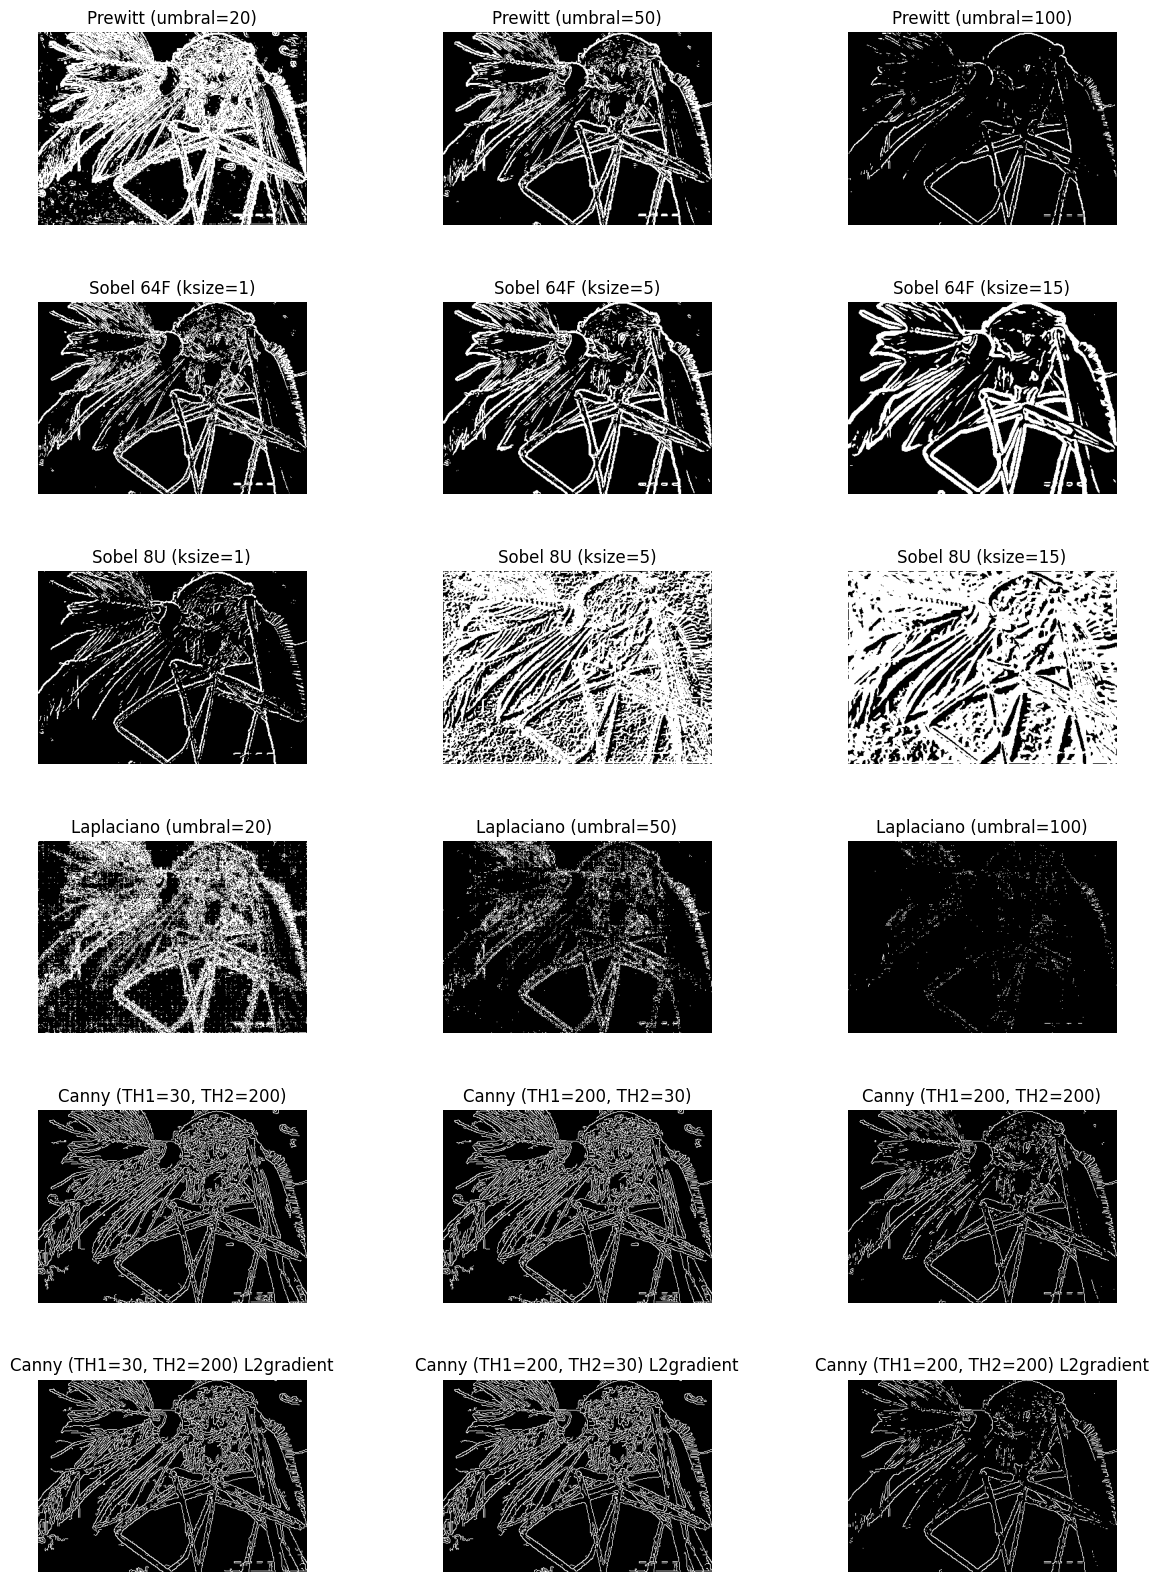

In [4]:
img = cv2.imread('imagenes/mosquito.jpg', cv2.IMREAD_GRAYSCALE)

# umbrales
u_bajo = 20
u_medio = 50
u_alto = 100

# kernels
ksize_bajo = 1
ksize_medio = 5
ksize_alto = 15

# Prewitt
prewitt_mag = aplicar_prewitt(img)
img_prewitt_1 = binarizar(prewitt_mag, u_bajo)
img_prewitt_2 = binarizar(prewitt_mag, u_medio)
img_prewitt_3 = binarizar(prewitt_mag, u_alto)

# Sobel
ddepth_sobel = cv2.CV_64F
sobel_1 = aplicar_sobel(img=img, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_bajo, bidireccional=True)
img_sobel_1 = binarizar(sobel_1, u_medio)
sobel_2 = aplicar_sobel(img=img, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_medio, bidireccional=True)
img_sobel_2 = binarizar(sobel_2, u_medio)
sobel_3 = aplicar_sobel(img=img, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_alto, bidireccional=True)
img_sobel_3 = binarizar(sobel_3, u_medio)

ddepth_sobel = cv2.CV_8U
sobel_4 = aplicar_sobel(img=img, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_bajo, bidireccional=True)
img_sobel_4 = binarizar(sobel_4, u_medio)
sobel_5 = aplicar_sobel(img=img, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_medio, bidireccional=True)
img_sobel_5 = binarizar(sobel_5, u_medio)
sobel_6 = aplicar_sobel(img=img, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_alto, bidireccional=True)
img_sobel_6 = binarizar(sobel_6, u_medio)

# Laplaciano
laplacian = cv2.Laplacian(img, cv2.CV_64F)

img_laplacian_1 = binarizar(laplacian, u_bajo)
img_laplacian_2 = binarizar(laplacian, u_medio)
img_laplacian_3 = binarizar(laplacian, u_alto)

# Canny
# sin L2gradient
img_canny_1 = cv2.Canny(img, 30, 200, L2gradient=False)
img_canny_2 = cv2.Canny(img, 200, 30, L2gradient=False)
img_canny_3 = cv2.Canny(img, 200, 200, L2gradient=False)

# Con L2gradient
img_canny_4 = cv2.Canny(img, 30, 200, L2gradient=True)
img_canny_5 = cv2.Canny(img, 200, 30, L2gradient=True)
img_canny_6 = cv2.Canny(img, 200, 200, L2gradient=True)

fig, ax = plt.subplots(6, 3, figsize=(15, 20))
plt.subplots_adjust(hspace=0.4, wspace=0.15)

ax[0,0].imshow(img_prewitt_1, cmap='gray'); ax[0,0].set_title(f"Prewitt (umbral={u_bajo})"); ax[0,0].axis('off')
ax[0,1].imshow(img_prewitt_2, cmap='gray'); ax[0,1].set_title(f"Prewitt (umbral={u_medio})"); ax[0,1].axis('off')
ax[0,2].imshow(img_prewitt_3, cmap='gray'); ax[0,2].set_title(f"Prewitt (umbral={u_alto})"); ax[0,2].axis('off')

ax[1,0].imshow(img_sobel_1, cmap='gray'); ax[1,0].set_title(f"Sobel 64F (ksize={ksize_bajo})"); ax[1,0].axis('off')
ax[1,1].imshow(img_sobel_2, cmap='gray'); ax[1,1].set_title(f"Sobel 64F (ksize={ksize_medio})"); ax[1,1].axis('off')
ax[1,2].imshow(img_sobel_3, cmap='gray'); ax[1,2].set_title(f"Sobel 64F (ksize={ksize_alto})"); ax[1,2].axis('off')

ax[2,0].imshow(img_sobel_4, cmap='gray'); ax[2,0].set_title(f"Sobel 8U (ksize={ksize_bajo})"); ax[2,0].axis('off')
ax[2,1].imshow(img_sobel_5, cmap='gray'); ax[2,1].set_title(f"Sobel 8U (ksize={ksize_medio})"); ax[2,1].axis('off')
ax[2,2].imshow(img_sobel_6, cmap='gray'); ax[2,2].set_title(f"Sobel 8U (ksize={ksize_alto})"); ax[2,2].axis('off')

ax[3,0].imshow(img_laplacian_1, cmap='gray'); ax[3,0].set_title(f"Laplaciano (umbral={u_bajo})"); ax[3,0].axis('off')
ax[3,1].imshow(img_laplacian_2, cmap='gray'); ax[3,1].set_title(f"Laplaciano (umbral={u_medio})"); ax[3,1].axis('off')
ax[3,2].imshow(img_laplacian_3, cmap='gray'); ax[3,2].set_title(f"Laplaciano (umbral={u_alto})"); ax[3,2].axis('off')

ax[4,0].imshow(img_canny_1, cmap='gray'); ax[4,0].set_title(f"Canny (TH1={30}, TH2={200})"); ax[4,0].axis('off')
ax[4,1].imshow(img_canny_2, cmap='gray'); ax[4,1].set_title(f"Canny (TH1={200}, TH2={30})"); ax[4,1].axis('off')
ax[4,2].imshow(img_canny_3, cmap='gray'); ax[4,2].set_title(f"Canny (TH1={200}, TH2={200})"); ax[4,2].axis('off')

ax[5,0].imshow(img_canny_4, cmap='gray'); ax[5,0].set_title(f"Canny (TH1={30}, TH2={200}) L2gradient"); ax[5,0].axis('off')
ax[5,1].imshow(img_canny_5, cmap='gray'); ax[5,1].set_title(f"Canny (TH1={200}, TH2={30}) L2gradient"); ax[5,1].axis('off')
ax[5,2].imshow(img_canny_6, cmap='gray'); ax[5,2].set_title(f"Canny (TH1={200}, TH2={200}) L2gradient"); ax[5,2].axis('off')

plt.show()

El laplaciano amplifica mucho el ruido, por lo que no sirve para ningun escenario de la imagen del mosquito, aunque funciona bien con la imagen artificial de patros de grises. Esto se debe a que busca los cruces por cero matemático con la segunda derivada, lo que la hace más sensible a cambios bruscos y aleatorios (como el ruido de alta frecuencia).

El pre-procesamiento interno que incorpora Canny es el suavizado gaussiano, lo cual limpia el ruido de alta frecuencia. Además, el umbral por histéresis da mayor control sobre la salida.

Todos los filtros fallan en cierta medida en zonas con textura compleja

##  Ejercicio 2: Transformada de Hough (TH)

Detectaremos puntos colineales y segmentos utilizando la Transformada de Hough Standard y Probabilística.

In [5]:
# Transformada de Hough Interactiva
def hough_interactivo(img_path, threshold, minLineLength, maxLineGap):
    img = cv2.imread(f"imagenes/{img_path}", cv2.IMREAD_GRAYSCALE)
    if img is None: return "Cargar imagen de prueba"

    # 1. Preprocesamiento: Detectar bordes primero (Obligatorio para Hough)
    bordes = cv2.Canny(img, 50, 150, apertureSize=3)

    # Hough standard
    img_hough = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    lines = cv2.HoughLines(bordes, rho=1, theta=np.pi/180, threshold=threshold)
    for line in lines:
        rho, theta = line[0]

        # coordenadas polares a cartesianas
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho

        # lineas
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        # Dibujamos la recta en la imagen (Color Azul en BGR)
        cv2.line(img_hough, (x1, y1), (x2, y2), (255, 0, 0), 2)

    # Hough probabilistico
    img_hough_p = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    lines = cv2.HoughLinesP(bordes, rho=1, theta=np.pi/180, threshold=threshold, minLineLength=minLineLength, maxLineGap=maxLineGap)

    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Dibujamos el segmento acotado (Color Rojo en BGR)
        cv2.line(img_hough_p, (x1, y1), (x2, y2), (0, 0, 255), 2)

    fig, ax = plt.subplots(1, 4, figsize=(15, 5))
    plt.subplots_adjust(hspace=0.4, wspace=0.15)

    ax[0].imshow(img, cmap='gray'); ax[0].set_title(f"Original"); ax[0].axis('off')
    ax[1].imshow(bordes, cmap='gray'); ax[1].set_title(f"Original"); ax[1].axis('off')
    ax[2].imshow(img_hough); ax[2].set_title(f"Hough Standard"); ax[2].axis('off')
    ax[3].imshow(img_hough_p); ax[3].set_title(f"Hough Probabilistico"); ax[3].axis('off');

interact(hough_interactivo,
         img_path=Dropdown(options=['building.jpg', 'letras1.tif', 'letras2.tif', 'snowman.png'], value='building.jpg'),
         threshold=IntSlider(min=10, max=300, value=100),
         minLineLength=IntSlider(min=1, max=200, value=50),
         maxLineGap=IntSlider(min=1, max=50, value=10));


interactive(children=(Dropdown(description='img_path', options=('building.jpg', 'letras1.tif', 'letras2.tif', …

**Reflexiona sobre lo que observas:**

* Un punto aislado en el espacio de la imagen, ¿qué forma geométrica genera en el espacio de parámetros $(\rho,\theta)$ del acumulador de Hough?

* Al usar **HoughLines** (Standard) sobre la imagen building.jpg, notará que dibuja rectas que atraviesan toda la imagen. ¿Por qué **HoughLinesP** (Probabilística) es más útil para evitar esto y cómo influye el parámetro **maxLineGap** al detectar ventanas o ladrillos?

##  Ejercicio 3: Segmentación mediante crecimiento de regiones

Implementaremos un algoritmo de **Region Growing** que se expande desde una semilla (**seed**) evaluando la homogeneidad de los píxeles vecinos.

In [ ]:
# Crecimiento de Regiones

def crecimiento_regiones(x_seed, y_seed, tolerancia):
    # Cargar imagen médica de prueba (Asegurate de tener una en tu entorno)
    img = cv2.imread('medica.jpg', cv2.IMREAD_GRAYSCALE)
    if img is None: return "Sube una imagen médica ('medica.jpg')"

    # Matriz para marcar los píxeles visitados/segmentados
    mascara = np.zeros_like(img)
    h, w = img.shape

    # Valor del píxel semilla
    valor_semilla = int(img[y_seed, x_seed])

    # TODO: Implementar la lógica iterativa (o recursiva) de Crecimiento de Regiones
    # Pista: Usa una lista a modo de pila (stack) para guardar los píxeles a evaluar.
    # Mientras la pila tenga elementos:
    #   1. Sacar pixel (x,y)
    #   2. Si no fue visitado y abs(img[y,x] - valor_semilla) <= tolerancia:
    #        marcar en mascara[y,x] = 255
    #        agregar vecinos (x+1,y), (x-1,y), (x,y+1), (x,y-1) a la pila

    # Dibujar la semilla en rojo para visualizar dónde empezamos
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.circle(img_color, (x_seed, y_seed), 3, (0, 0, 255), -1)

    mostrar_imagenes([img_color, mascara], ["Original con Semilla", f"Segmentación (Tol={tolerancia})"])

# Sliders para interactuar con la posición de la semilla y la tolerancia
interact(crecimiento_regiones,
         x_seed=IntSlider(min=0, max=255, value=128), # Ajustar max al ancho de tu imagen
         y_seed=IntSlider(min=0, max=255, value=128), # Ajustar max al alto de tu imagen
         tolerancia=IntSlider(min=1, max=50, value=10))



**Reflexiona sobre lo que observas:**

A diferencia de un simple umbralizado global (**cv2.threshold** o **cv2.inRange**), el crecimiento de regiones exige conectividad espacial.

¿En qué situaciones médicas (ej: resonancias o radiografías) un simple rango de grises fallaría garrafalmente pero el crecimiento de regiones tendría éxito?

##  Ejercicio 4: Segmentación en color y etiquetado (Componentes Conectadas)

Automatizaremos el conteo de rosas en la imagen **rosas.jpg** extrayendo regiones y descartando el ruido.

* Puede investigar con que funciones de OpenCV puede obtener más infor-
mación de las regiones, por ejemplo: tamaño de las regiones, tamaño promedio, cantidad de regiones bajo y sobre la media, tasa de circularidad, etc: **cv.connectedComponentsWithStats, cv.minEnclosingCircle(), cv.minAreaRect()**, etc.

---

* Nota: para descartar el ruido puede hacerlo usando filtros de medias y procesos ad-hoc como ya lo vimos previamente. O bien, puede usar **cv2.erode, cv2.dilate, cv2.morphologyEx** (apertura o cierre) para limpiar manchas sueltas. Ésto lo veremos en detalle en la unidad de morfología pero puede ver simplemente la forma de uso de estas operaciones y usarlas aquí.

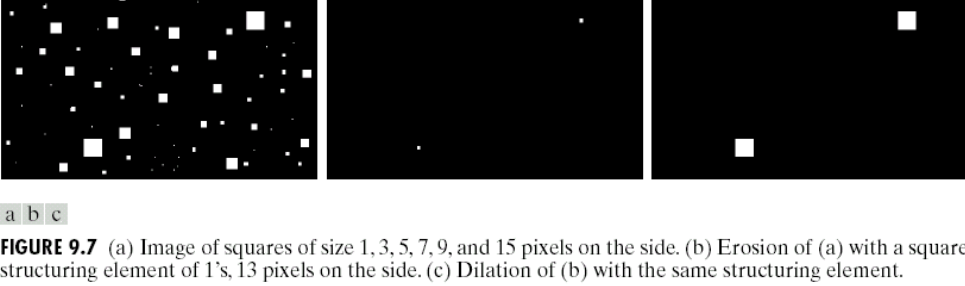

In [ ]:
#Componentes Conectadas

def contar_rosas():
    img = cv2.imread('rosas.jpg')
    if img is None: return "Cargar 'rosas.jpg'"

    # 1. Segmentación por color (Similar al TP04)
    # TODO: Convertir a HSV y hacer cv2.inRange para aislar los pétalos rojos/rosas
    # mascara = ...
    mascara = np.zeros(img.shape[:2], dtype=np.uint8) # REEMPLAZAR

    # 2. Mejorar la máscara (Descartar ruido morfológico)
    # TODO: Aplicar cv2.morphologyEx (apertura o cierre) para limpiar manchas sueltas.
    mascara_limpia = mascara.copy() # REEMPLAZAR

    # 3. Etiquetado de componentes conectadas
    # Estudie esta función:
    # retval, labels, stats, centroids = cv2.connectedComponentsWithStats(mascara_limpia)
    # TODO: Implementar función de openCV.
    retval = 0
    centroids = [] # Asegurate de llenar esto
    stats = []

    # 4. Filtrar y contar rosas automáticas (descartando regiones muy chicas)
    # for i in range(1, retval): # Empezamos en 1 para ignorar el fondo (etiqueta 0)
    #     area = stats[i, cv2.CC_STAT_AREA]
    #     if area > umbral_area_minima:
    #         cx, cy = int(centroids[i]), int(centroids[i][1])
    #         cv2.circle(img, (cx, cy), 10, (0, 255, 0), -1) # Dibujar centro

    # print(f"Cantidad de rosas detectadas: {cantidad_rosas_reales}")

    mostrar_imagenes([cv2.cvtColor(img, cv2.COLOR_BGR2RGB), mascara_limpia],
                     ["Conteo Automático", "Máscara Limpia"])

contar_rosas()


**Reflexiona sobre lo que observas:**

* Antes de aplicar el etiquetado de componentes conectadas (**connectedComponents**), fue necesario aplicar un filtrado morfológico (limpieza de ruido). ¿Qué habría ocurrido con el recuento automático (retval) si hubiéramos dejado pequeñas manchas de ruido aisladas en la máscara binaria?

* ¿En qué se diferencia fundamentalmente la lógica de búsqueda de las "Componentes conectadas" frente al algoritmo de "Crecimiento de regiones" implementado en el ejercicio anterior?


##  Ejercicio 5: Aplicaciones Prácticas

Utilizaremos la transformada de Hough circular para discriminar objetos (ejemplo: latas de pie en una toma desde arriba) y Hough de líneas para encontrar pistas de aterrizaje.

---

Tenga en cuenta que el método debe ser útil para imágenes de otros aeropuertos, con caracterı́sticas similares pero con variaciones en la localización, el largo de la pista, la inclinación de la pista, etc.

Para probar la robustez de su código, se le sugiere que genere imágenes rotadas y/o desplazadas de las propuestas.

In [ ]:
#  Conteo y discriminación de Latas (Hough Circles)

def detectar_latas():
    img = cv2.imread('latas.png')
    if img is None: return "Cargar 'latas.png'"

    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Preprocesamiento recomendado para HoughCircles
    img_blur = cv2.medianBlur(img_gris, 5)

    # TODO: Configurar cv2.HoughCircles
    # Param2: Acumulador (menor = más círculos falsos). minDist: distancia mínima entre centros.
    # circles = cv2.HoughCircles(img_blur, cv2.HOUGH_GRADIENT, dp=1, minDist=20,
    #                            param1=50, param2=30, minRadius=10, maxRadius=50)

    # TODO: Iterar sobre 'circles', dibujar circunferencias, e implementar una
    # lógica if/else evaluando el radio para contar cuántas latas son grandes y cuántas chicas.

    # print(f"Total: X | Grandes: Y | Chicas: Z")
    mostrar_imagenes([img], ["Detección de Latas"])

detectar_latas()


In [ ]:
#Segmentación de Pistas de Aeropuerto

def detectar_pista_aeropuerto(img_path='corrientes_ruidogris.jpg'):
    img = cv2.imread(img_path)
    if img is None: return f"Cargar {img_path}"

    # 1. Preprocesamiento (Eliminar ruido gaussiano e impulsivo)
    # TODO: Recordar TP06. ¿Qué filtro es el mejor para mezcla de ruido impulsivo severo?
    # img_limpia = cv2.medianBlur(img, 5) # Ejemplo
    img_limpia = img.copy() # REEMPLAZAR

    # 2. Detección de Bordes (Canny)
    # bordes = cv2.Canny(...)

    # 3. Transformada de Hough (Líneas)
    # TODO: Usar HoughLines o HoughLinesP.
    # TIP DE ROBUSTEZ: Una pista de aterrizaje está formada por los segmentos colineales más
    # LARGOS de la imagen. Filtre los resultados de Hough descartando líneas cortas
    # o agrupando las que tengan ángulos paralelos.

    # for line in lineas_filtradas:
    #     cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 3) # Dibujar en Rojo

    mostrar_imagenes([img], ["Pista Principal Detectada"])

detectar_pista_aeropuerto('corrientes_ruidogris.jpg')

**Reflexiona sobre lo que observas:**

* En la detección de círculos, **cv2.HoughCircles** no requiere que usted calcule Canny previamente de forma explícita, sino que lo hace internamente (controlado por param1). Si el parámetro param2 (umbral del acumulador de centros) se ajusta muy bajo, ¿qué falsos positivos geométricos podrían empezar a aparecer en la imagen de las latas?

* En las imágenes satelitales del aeropuerto, ¿cómo logró su algoritmo discriminar las líneas de la pista principal frente a las decenas de otras líneas rectas provenientes de las calles aledañas, hangares o la terminal?


#  Ejercicios Extras: Evaluación de la calidad de segmentación

En la práctica, una vez que aplicamos un algoritmo de segmentación (Nuestra "Predicción"), necesitamos medir qué tan bien lo hizo comparándolo contra una segmentación ideal o manual (Nuestro "Ground-Truth" o GT)

A continuación, exploraremos cómo calcular estas métricas manualmente y utilizando librerías especializadas.


## Cálculo Manual de IoU

In [ ]:
# Ejemplo Base: Cálculo Manual de IoU

import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Crear las matrices que contienen las máscaras (512x512)
gt = np.zeros((512,512), np.uint8)
pred = np.zeros((512,512), np.uint8)

# 2. Dibujo el ground-truth (centro 150,150) y la predicción ligeramente desplazada (180,150)
cv2.circle(gt, (150,150), 100, 255, -1)
cv2.circle(pred, (180,150), 100, 255, -1)

# 3. Computo manualmente la Unión y la Intersección
intersection = np.zeros((512,512), np.uint8)
union = np.zeros((512,512), np.uint8)

cv2.bitwise_and(gt, pred, intersection)
cv2.bitwise_or(gt, pred, union)

# 4. Computo IoU (Intersection over Union / Índice de Jaccard)
iou = cv2.sumElems(intersection)[0] / cv2.sumElems(union)[0]
print(f"Cálculo Manual -> Intersection over Union (IoU) = {iou:.4f}")

# Visualización
plt.figure(figsize=(6,6))
plt.imshow(gt, cmap='Blues')
plt.imshow(pred, cmap='Reds', alpha=0.5)
plt.title("Ground Truth (Azul) vs Predicción (Rojo)")
plt.axis('off')
plt.show()

## Instalación y uso de MedPy

La biblioteca medpy que incluye diversas métricas listas para usar

In [ ]:
# Instalación y uso de MedPy
!pip3 install medpy -q

import medpy.metric as metrics

print("--- Métricas con MedPy (Círculo desplazado 30px) ---")
print(f"Dice (F1-Score): {metrics.dc(pred, gt):.4f}")
print(f"Jaccard (IoU): {metrics.jc(pred, gt):.4f}")
print(f"Hausdorff Distance: {metrics.hd(pred, gt):.4f}")
print(f"Average Surface Distance: {metrics.assd(pred, gt):.4f}")

## Ejercicio Extra 1: La sensibilidad al ruido (El problema de Hausdorff)

La Distancia de Hausdorff mide la distancia máxima entre los bordes de ambas segmentaciones

* ¿Qué pasa si nuestro algoritmo de segmentación fue casi perfecto, pero dejó una pequeña "basurita" o ruido en otra parte de la imagen?

---

**Analiza los resultados impresos**. ¿Cuál métrica se destruyó por completo y cuáles casi no se inmutaron?

In [ ]:
# Sensibilidad al Ruido

# Hacemos una copia de la predicción original
pred_ruidosa = pred.copy()

# Introducimos un pequeño cuadrado de ruido (falso positivo) lejos del objeto
pred_ruidosa[450:460, 450:460] = 255

print("--- Métricas con ruido alejado ---")
# TODO: Calcula e imprime nuevamente las métricas de Dice, Jaccard, HD y ASSD usando pred_ruidosa y gt
# print(f"Dice: {metrics.dc(pred_ruidosa, gt):.4f}")
# print(f"Hausdorff Distance: {metrics.hd(pred_ruidosa, gt):.4f}")

plt.figure(figsize=(6,6))
plt.imshow(gt, cmap='Reds')
plt.imshow(pred_ruidosa, cmap='Blues', alpha=0.5)
plt.title("Predicción con ruido alejado")
plt.axis('off')
plt.show()



## Ejercicio Extra 2: Cálculo Manual del Coeficiente de Dice

Ya viste cómo calcular el IoU (Jaccard) manualmente. Ahora te toca implementar el Coeficiente de Dice sin usar MedPy.
La fórmula matemática de Dice para imágenes binarias es:
$$Dice = \frac{2 \cdot |GT \cap PRED|}{|GT| + |PRED|}$$


In [ ]:
# Dice Manual

def calcular_dice_manual(mascara_gt, mascara_pred):
    # Asegurarnos de que sean booleanas o 0/1 para sumar áreas correctamente
    gt_bin = (mascara_gt > 0).astype(np.float32)
    pred_bin = (mascara_pred > 0).astype(np.float32)

    # TODO: Calcula la intersección (área donde ambas son 1)
    # interseccion = np.sum(gt_bin * pred_bin)
    interseccion = 0 # REEMPLAZAR

    # TODO: Calcula el área total de GT y de PRED
    # area_gt = np.sum(gt_bin)
    # area_pred = ...

    # TODO: Aplica la fórmula de Dice
    # dice = (2.0 * interseccion) / (area_gt + area_pred)
    dice = 0 # REEMPLAZAR

    return dice

dice_calculado = calcular_dice_manual(gt, pred)
dice_medpy = metrics.dc(pred, gt)

print(f"Dice Manual: {dice_calculado:.4f}")
print(f"Dice MedPy:  {dice_medpy:.4f}")
# TODO: ¡Verifica que ambos den exactamente el mismo resultado!


## Ejercicio Extra 3: Evaluación de Escala (Over-segmentation vs Under-segmentation)

¿Qué ocurre con las métricas cuando nuestro algoritmo encuentra el centro perfecto del objeto, pero lo segmenta mucho más grande (sobre-segmentación) o mucho más chico (sub-segmentación) de lo que debería?

In [ ]:
# Evaluación de Escala

# Creamos un Ground Truth de radio 100
gt_escala = np.zeros((512,512), np.uint8)
cv2.circle(gt_escala, (256,256), 100, 255, -1)

# TODO: Crea una predicción "pred_chica" centrada en el mismo lugar (256,256) pero con radio 50
pred_chica = np.zeros((512,512), np.uint8)
# cv2.circle(...)

# TODO: Crea una predicción "pred_grande" centrada en el mismo lugar pero con radio 150
pred_grande = np.zeros((512,512), np.uint8)
# cv2.circle(...)

# TODO: Calcula e imprime Jaccard y Dice para ambos casos.
# print("--- Predicción Sub-segmentada (Chica) ---")
# ...
# print("--- Predicción Sobre-segmentada (Grande) ---")
# ...

# TODO: Visualización comparativa

## Reflexiones Guía - Evaluación de Segmentación

**Reflexiona sobre lo que observas:**

* En el Ejercicio 1, al introducir un pequeño cuadro de ruido lejano, Jaccard y Dice apenas bajaron unas décimas, pero la Distancia de Hausdorff pasó de 30 a más de 300. ¿Por qué crees que Hausdorff es tan extremadamente sensible a un solo píxel falso positivo lejano? Si estuvieras evaluando un algoritmo para detectar tumores en radiografías, **¿qué métrica te preocuparía más?**

* Observando la fórmula del Ejercicio 2, ¿qué pasaría matemáticamente si le pasas a la función dos imágenes completamente en negro (donde no hay objeto ni en el GT ni en la predicción)? **¿Cómo solucionarías ese error en tu código?**

* En el Ejercicio 3, comparando una segmentación que se quedó corta frente a una que se pasó de largo, ¿las métricas de solapamiento **(IoU/Dice)** penalizan más la sub-segmentación o la sobre-segmentación, o las penalizan por igual?